# Hospital Readmission Risk Modeling

## 1. Objective

## 2. Setup

## 3. Load Raw Data

## 4. Initial Data Inspection

# Hospital Readmission Risk Modeling

### Predicting 30-Day Readmission Risk for Diabetic Patients

This notebook develops a machine learning pipeline to predict whether a hospital encounter will result in a readmission within 30 days.

The modeling workflow includes:

- data auditing and preprocessing
- feature engineering informed by clinical context
- baseline modeling using regularized logistic regression
- nonlinear modeling using XGBoost
- model evaluation using ROC and precision–recall analysis
- model interpretation using feature importance and SHAP values

The goal is to produce well-calibrated risk estimates that could support clinical decision-making for prioritizing post-discharge interventions.

In [15]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

# Optional display settings for easier inspection
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)


PROJECT_ROOT = Path.cwd().resolve().parent
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"

print("Project root:", PROJECT_ROOT)
print("Raw data dir:", DATA_RAW_DIR)

# Make src importable from notebook
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

Project root: /Users/bhavanasanghi/Desktop/hospital-readmission-risk
Raw data dir: /Users/bhavanasanghi/Desktop/hospital-readmission-risk/data/raw


In [16]:
DIABETES_DATA_PATH = DATA_RAW_DIR / "diabetic_data.csv"
IDS_MAPPING_PATH = DATA_RAW_DIR / "IDS_mapping.csv"

df = pd.read_csv(DIABETES_DATA_PATH)
ids_map = pd.read_csv(IDS_MAPPING_PATH)

print("diabetic_data shape:", df.shape)
print("IDS_mapping shape:", ids_map.shape)

diabetic_data shape: (101766, 50)
IDS_mapping shape: (67, 2)


In [17]:
display(df.head())
display(ids_map.head())

print("\nColumns in diabetic_data:")
print(df.columns.tolist())

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available



Columns in diabetic_data:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [18]:
print("Data types:\n")
display(df.dtypes)

print("\nMissing values (top 20 by count):\n")
display(df.isna().sum().sort_values(ascending=False).head(20))

print("\nTarget distribution for readmitted:\n")
display(df["readmitted"].value_counts(dropna=False))
display(df["readmitted"].value_counts(normalize=True, dropna=False))

Data types:



encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         


Missing values (top 20 by count):



max_glu_serum          96420
A1Cresult              84748
encounter_id               0
nateglinide                0
glimepiride                0
acetohexamide              0
glipizide                  0
glyburide                  0
tolbutamide                0
pioglitazone               0
rosiglitazone              0
acarbose                   0
miglitol                   0
troglitazone               0
tolazamide                 0
examide                    0
citoglipton                0
insulin                    0
glyburide-metformin        0
glipizide-metformin        0
dtype: int64


Target distribution for readmitted:



readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64

we see columns enoucnter_ID and patient_nbr. This could mean that there can be multiple hospital encounters per patient. Diagnosing that below

In [19]:
print("Total rows:", len(df))

print("Unique encounters:", df["encounter_id"].nunique())

print("Unique patients:", df["patient_nbr"].nunique())

encounters_per_patient = df.groupby("patient_nbr")["encounter_id"].count()

print("Average encounters per patient:", encounters_per_patient.mean())
print("Max encounters for a patient:", encounters_per_patient.max())

display(encounters_per_patient.describe())

Total rows: 101766
Unique encounters: 101766
Unique patients: 71518
Average encounters per patient: 1.4229424760200229
Max encounters for a patient: 40


count    71518.000000
mean         1.422942
std          1.090740
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         40.000000
Name: encounter_id, dtype: float64

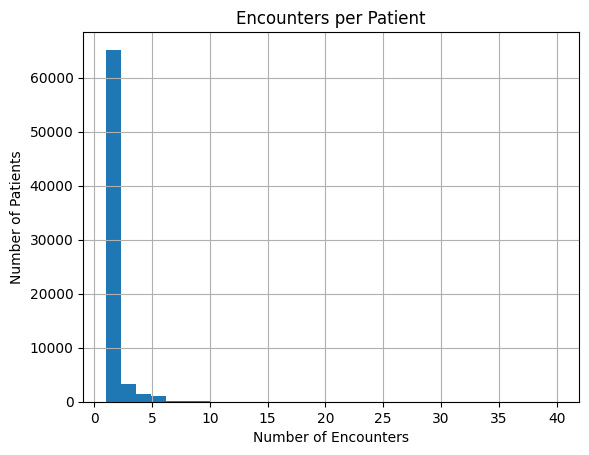

In [20]:
import matplotlib.pyplot as plt

encounters_per_patient.hist(bins=30)
plt.title("Encounters per Patient")
plt.xlabel("Number of Encounters")
plt.ylabel("Number of Patients")
plt.show()

# We need to decide what level the data should be in 

### option 1 - encounter level. But the same patient could appear multiple times and this could create data leakage if they appear in both training and test data with different encounter IDs

### option 2 - if we keep it a patient level and maybe keep only first encounter, or we will have to decide which encounter to keep, but will eventually lose data

### option 3 - we can maybe remove encounters where patient died or went to hospice. (We can get to know this from discharge_disposition_id where values 11,13,14,19,20,21 is expired or hospice) these patients can be readmitted. We can also ensure that patients with all encounters are present only in training or test and not both to prevent data leakage. 

### option 3 seems to be viable

### Why we should remove hospice patients 

#### whether home hospice or hospice medical facility, they are in end of life care and any subsequent hospital contact represents a qualitatively different event from the unplanned acute readmissions this model aims to predict. Including them would introduce noise into the target variable

In [21]:
discharge_exclude_ids = [11, 13, 14, 19, 20, 21]

print("Rows with excluded discharge dispositions:")
print(df["discharge_disposition_id"].isin(discharge_exclude_ids).sum())

print("\nDistribution of excluded discharge dispositions:")
display(
    df.loc[df["discharge_disposition_id"].isin(discharge_exclude_ids), "discharge_disposition_id"]
      .value_counts()
      .sort_index()
)

Rows with excluded discharge dispositions:
2423

Distribution of excluded discharge dispositions:


discharge_disposition_id
11    1642
13     399
14     372
19       8
20       2
Name: count, dtype: int64

In [22]:
initial_rows = len(df)

df = df[~df["discharge_disposition_id"].isin(discharge_exclude_ids)].copy()

print("Rows removed:", initial_rows - len(df))
print("Remaining rows:", len(df))

Rows removed: 2423
Remaining rows: 99343


In [23]:
df["readmitted"].value_counts()

df["readmitted"].value_counts(normalize=True)

readmitted
NO     0.528744
>30    0.357368
<30    0.113888
Name: proportion, dtype: float64

### Handling Missing Value Placeholders

In the dataset, missing values are frequently encoded as the string `"?"` rather than as proper null values.  
These placeholders are converted to `NaN` to ensure correct missing value handling

In [24]:
df = df.replace("?", np.nan)

print("Total missing values in dataset:")
print(df.isna().sum().sum())

print("Missing values after conversion (top 20):")
display(df.isna().sum().sort_values(ascending=False).head(20))



Total missing values in dataset:
364961
Missing values after conversion (top 20):


weight               96218
max_glu_serum        94191
A1Cresult            82509
medical_specialty    48616
payer_code           39398
race                  2234
diag_3                1419
diag_2                 356
diag_1                  20
encounter_id             0
troglitazone             0
tolbutamide              0
pioglitazone             0
rosiglitazone            0
acarbose                 0
miglitol                 0
citoglipton              0
tolazamide               0
examide                  0
glipizide                0
dtype: int64

### Early Feature Removal

Several variables exhibit extremely high missingness or limited modeling value.

- `weight` (>95% missing)
- `payer_code` (~40% missing with fragmented categories)

Laboratory markers such as A1C and maximum glucose levels were retained despite high missingness because the absence of a test can itself encode clinical decision-making. medical speciality could also be a signal because patient admitted by a cadiologist has a very different risk profile compared to the one admitted by a general practioner. In contrast, administrative variables such as payer code were removed due to high missingness combined with limited clinical interpretability and high categorical fragmentation

In [25]:
cols_to_drop = ["weight", "payer_code"]

df = df.drop(columns=cols_to_drop)

print("Remaining columns:", len(df.columns))
print(df.columns.tolist())

Remaining columns: 48
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


### Target Definition 

The modeling objective is to predict whether a patient encounter results in readmission within 30 days — a clinically established threshold used by the Centers for Medicare and Medicaid Services (CMS) as a hospital quality metric and tied directly to financial penalties for excess readmissions

The original readmitted field has three levels:

NO — not readmitted
>30 — readmitted after 30 days
<30 — readmitted within 30 days

The target is defined as a binary outcome:

1 = readmitted within 30 days (<30) — 11.4% of encounters
0 = not readmitted within 30 days (NO or >30) — 88.6% of encounters

Encounters with readmission after 30 days are treated as negative cases — later readmissions reflect chronic disease management patterns rather than acute care quality, and are clinically and operationally distinct from early unplanned returns


In [26]:
df["target_30day_readmit"] = (df["readmitted"] == "<30").astype(int)

print("Target distribution:")
display(df["target_30day_readmit"].value_counts())
display(df["target_30day_readmit"].value_counts(normalize=True))

print("\nCross-check against original readmitted column:")
display(pd.crosstab(df["readmitted"], df["target_30day_readmit"]))

Target distribution:


target_30day_readmit
0    88029
1    11314
Name: count, dtype: int64

target_30day_readmit
0    0.886112
1    0.113888
Name: proportion, dtype: float64


Cross-check against original readmitted column:


target_30day_readmit,0,1
readmitted,,
<30,0,11314
>30,35502,0
NO,52527,0


### Defining Modeling Dataset

Before model training, columns are separated into:

- **Feature variables** used for prediction
- **Target variable** representing 30-day readmission
- **Identifier columns** used for data management but excluded from modeling

Identifiers such as patient and encounter IDs are retained temporarily for dataset splitting and traceability but will not be used as predictive features.

In [27]:
TARGET_COL = "target_30day_readmit"

ID_COLS = [
    "encounter_id",
    "patient_nbr"
]

ORIGINAL_TARGET = "readmitted"

print("Target column:", TARGET_COL)
print("Identifier columns:", ID_COLS)

print("\nTotal columns:", len(df.columns))

Target column: target_30day_readmit
Identifier columns: ['encounter_id', 'patient_nbr']

Total columns: 49


### Train/Test Split Strategy

Because the dataset may contain multiple encounters for the same patient, a standard random row-level split would risk information leakage by allowing the same patient to appear in both training and test sets.

To prevent this, the dataset is split at the **patient level** using grouped splitting. All encounters associated with a given patient are assigned entirely to either the training set or the test set.

In [28]:
from sklearn.model_selection import GroupShuffleSplit

FEATURE_EXCLUDE_COLS = ID_COLS + [ORIGINAL_TARGET, TARGET_COL]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(df, groups=df["patient_nbr"])
)

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("Unique train patients:", train_df["patient_nbr"].nunique())
print("Unique test patients:", test_df["patient_nbr"].nunique())

overlap = set(train_df["patient_nbr"]).intersection(set(test_df["patient_nbr"]))
print("Patient overlap between train and test:", len(overlap))

Train shape: (79541, 49)
Test shape: (19802, 49)
Unique train patients: 55992
Unique test patients: 13998
Patient overlap between train and test: 0


In [29]:
print("Train target rate:")
display(train_df[TARGET_COL].value_counts(normalize=True).sort_index())

print("Test target rate:")
display(test_df[TARGET_COL].value_counts(normalize=True).sort_index())

Train target rate:


target_30day_readmit
0    0.885619
1    0.114381
Name: proportion, dtype: float64

Test target rate:


target_30day_readmit
0    0.888092
1    0.111908
Name: proportion, dtype: float64

### Feature Selection for Modeling

Before feature engineering and preprocessing, columns are separated into three groups:

**Target variable**
- `target_30day_readmit`

**Identifier columns (not used as predictors)**
- `encounter_id`
- `patient_nbr`

**Original label column**
- `readmitted`

All remaining columns are considered candidate features for modeling.

Identifier columns are retained temporarily for traceability but will be excluded from the model input.

In [30]:
EXCLUDE_FROM_MODEL = [
    "encounter_id",
    "patient_nbr",
    "readmitted",
    "target_30day_readmit"
]

feature_cols = [c for c in train_df.columns if c not in EXCLUDE_FROM_MODEL]

print("Number of feature columns:", len(feature_cols))
print(feature_cols)

Number of feature columns: 45
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [31]:
X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET_COL].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[TARGET_COL].copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (79541, 45)
X_test shape: (19802, 45)


### Feature Audit and Statistical Design Considerations

Before feature engineering, predictors are grouped by statistical type and clinical meaning.

This step is important for two reasons:

1. Different variables require different preprocessing strategies depending on whether they are numeric, ordinal, nominal, sparse, or high-cardinality.
2. Several predictors in this dataset carry domain-specific meaning (e.g., diagnosis codes, medication changes, lab results), so statistically appropriate transformations should also preserve clinical interpretability.

The feature design process therefore combines:
- statistical reasoning about scale, sparsity, and model behavior
- domain reasoning about disease severity, utilization history, and treatment complexity

In [33]:
feature_audit = pd.DataFrame({
    "feature": feature_cols,
    "dtype": [X_train[c].dtype for c in feature_cols],
    "n_unique_train": [X_train[c].nunique(dropna=True) for c in feature_cols],
    "missing_train": [X_train[c].isna().sum() for c in feature_cols],
    "missing_pct_train": [X_train[c].isna().mean() for c in feature_cols]
}).sort_values(["dtype", "n_unique_train"])

display(feature_audit)

,feature,dtype,n_unique_train,missing_train,missing_pct_train
9,num_procedures,int64,7,0,0.000000
3,admission_type_id,int64,8,0,0.000000
6,time_in_hospital,int64,14,0,0.000000
17,number_diagnoses,int64,16,0,0.000000
5,admission_source_id,int64,17,0,0.000000
4,discharge_disposition_id,int64,21,0,0.000000
13,number_inpatient,int64,21,0,0.000000
12,number_emergency,int64,29,0,0.000000
11,number_outpatient,int64,35,0,0.000000
10,num_medications,int64,75,0,0.000000


In [36]:
numeric_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

ordinal_features = [
    "age"
]

lab_result_features = [
    "max_glu_serum",
    "A1Cresult"
]

diagnosis_features = [
    "diag_1", "diag_2", "diag_3"
]

id_encoded_features = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

contextual_features = [
    "medical_specialty"
]

medication_features = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide",
    "glimepiride", "acetohexamide", "glipizide", "glyburide",
    "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose",
    "miglitol", "troglitazone", "tolazamide", "examide",
    "citoglipton", "insulin", "glyburide-metformin",
    "glipizide-metformin", "glimepiride-pioglitazone",
    "metformin-rosiglitazone", "metformin-pioglitazone"
]

binary_features = [
    "change",
    "diabetesMed"
]

nominal_features = [
    "race",
    "gender"
]

In [37]:
all_grouped = (
    numeric_features
    + ordinal_features
    + lab_result_features
    + diagnosis_features
    + id_encoded_features
    + contextual_features
    + medication_features
    + binary_features
    + nominal_features
)

print("Total grouped features:", len(all_grouped))
print("Total feature_cols:", len(feature_cols))

missing_from_groups = sorted(set(feature_cols) - set(all_grouped))
extra_in_groups = sorted(set(all_grouped) - set(feature_cols))

print("Missing from groups:", missing_from_groups)
print("Extra in groups:", extra_in_groups)

Total grouped features: 45
Total feature_cols: 45
Missing from groups: []
Extra in groups: []


In [38]:
print("\nFeature counts by group")

groups = {
    "numeric": numeric_features,
    "ordinal": ordinal_features,
    "lab_results": lab_result_features,
    "diagnosis": diagnosis_features,
    "id_encoded": id_encoded_features,
    "contextual": contextual_features,
    "medications": medication_features,
    "binary": binary_features,
    "nominal": nominal_features
}

for name, cols in groups.items():
    print(f"{name:15s} : {len(cols)}")


Feature counts by group
numeric         : 8
ordinal         : 1
lab_results     : 2
diagnosis       : 3
id_encoded      : 3
contextual      : 1
medications     : 23
binary          : 2
nominal         : 2


In [39]:
feature_group_map = {}

for col in numeric_features:
    feature_group_map[col] = "numeric"

for col in ordinal_features:
    feature_group_map[col] = "ordinal"

for col in lab_result_features:
    feature_group_map[col] = "lab_result"

for col in diagnosis_features:
    feature_group_map[col] = "diagnosis"

for col in id_encoded_features:
    feature_group_map[col] = "id_encoded_categorical"

for col in contextual_features:
    feature_group_map[col] = "contextual_categorical"

for col in medication_features:
    feature_group_map[col] = "medication_status"

for col in binary_features:
    feature_group_map[col] = "binary"

for col in nominal_features:
    feature_group_map[col] = "nominal"

In [40]:
feature_audit = pd.DataFrame({
    "feature": feature_cols,
    "group": [feature_group_map[c] for c in feature_cols],
    "raw_dtype": [X_train[c].dtype for c in feature_cols],
    "n_unique_train": [X_train[c].nunique(dropna=True) for c in feature_cols],
    "missing_train": [X_train[c].isna().sum() for c in feature_cols],
    "missing_pct_train": [X_train[c].isna().mean() for c in feature_cols]
})

feature_audit = feature_audit.sort_values(["group", "feature"]).reset_index(drop=True)

display(feature_audit)

,feature,group,raw_dtype,n_unique_train,missing_train,missing_pct_train
0,change,binary,object,2,0,0.000000
1,diabetesMed,binary,object,2,0,0.000000
2,medical_specialty,contextual_categorical,object,72,38914,0.489232
3,diag_1,diagnosis,object,700,15,0.000189
4,diag_2,diagnosis,object,718,296,0.003721
5,diag_3,diagnosis,object,760,1169,0.014697
6,admission_source_id,id_encoded_categorical,int64,17,0,0.000000
7,admission_type_id,id_encoded_categorical,int64,8,0,0.000000
8,discharge_disposition_id,id_encoded_categorical,int64,21,0,0.000000
9,A1Cresult,lab_result,object,3,66058,0.830490


In [45]:
treatment_map = {
    # numeric
    "time_in_hospital": "keep numeric; scale for logistic regression",
    "num_lab_procedures": "keep numeric; inspect skew; scale for logistic regression",
    "num_procedures": "keep numeric; inspect skew; scale for logistic regression",
    "num_medications": "keep numeric; inspect skew; scale for logistic regression",
    "number_outpatient": "keep numeric; zero-inflated; engineer any_prior_outpatient flag",
    "number_emergency": "keep numeric; zero-inflated; engineer any_prior_ed flag",
    "number_inpatient": "keep numeric; zero-inflated; engineer any_prior_inpatient flag",
    "number_diagnoses": "keep numeric; proxy for comorbidity burden",

    # ordinal
    "age": (
        "convert string buckets to ordered numeric representation; "
        "midpoint encoding preferred for logistic regression; "
        "ordinal index acceptable for tree models"
    ),

    # lab results
    "max_glu_serum": (
        "treat as categorical; fill missing -> Not_Measured; "
        "missing likely indicates test not ordered"
    ),
    "A1Cresult": (
        "treat as categorical; fill missing -> Not_Measured; "
        "preserve ordered severity levels if useful"
    ),

    # diagnosis
    "diag_1": "map ICD-9 code to broad clinical category; derive primary-diagnosis flags",
    "diag_2": "map ICD-9 code to broad clinical category",
    "diag_3": "map ICD-9 code to broad clinical category",

    # id-encoded categoricals
    "admission_type_id": "map ID to label using IDS_mapping; treat as categorical",
    "discharge_disposition_id": (
        "map ID to label using IDS_mapping; treat as categorical; "
        "valid if prediction occurs at discharge"
    ),
    "admission_source_id": "map ID to label using IDS_mapping; treat as categorical",

    # contextual
    "medical_specialty": "fill missing with Unknown; collapse rare categories into Other",

    # binary
    "change": "encode Yes/No -> binary 1/0",
    "diabetesMed": "encode Yes/No -> binary 1/0",

    # nominal
    "race": "treat as categorical; keep Unknown category; evaluate subgroup performance later",
    "gender": "treat as categorical; retain Unknown/Invalid category if present"
}

# medication handling
for col in medication_features:
    treatment_map[col] = (
        "categorical medication status (No/Steady/Up/Down); "
        "engineer derived signals such as active_med_flag and changed_med_flag; "
        "aggregate into n_active_meds, n_med_changes, insulin_flag, insulin_change"
    )

feature_audit["recommended_treatment"] = feature_audit["feature"].map(treatment_map)

In [46]:
notes_map = {
    "time_in_hospital": "Length-of-stay severity proxy",
    "num_lab_procedures": "Diagnostic workup intensity during encounter",
    "num_procedures": "Procedure burden during hospitalization",
    "num_medications": "Treatment complexity proxy",
    "number_outpatient": "Prior outpatient utilization history",
    "number_emergency": "Prior emergency-care utilization",
    "number_inpatient": "Strong prior utilization / instability signal",
    "number_diagnoses": "Proxy for comorbidity burden",

    "age": "Stored as ordered string buckets representing age ranges",

    "max_glu_serum": (
        "Extremely high missingness likely indicates test not ordered; "
        "missingness itself may carry signal"
    ),
    "A1Cresult": (
        "High missingness likely reflects test not ordered rather than random missingness"
    ),

    "diag_1": "Primary ICD-9 diagnosis code",
    "diag_2": "Secondary ICD-9 diagnosis code",
    "diag_3": "Tertiary ICD-9 diagnosis code",

    "admission_type_id": (
        "Integer-coded categorical variable; numeric values have no arithmetic meaning"
    ),
    "discharge_disposition_id": (
        "Discharge outcome category; may reflect care pathway decisions"
    ),
    "admission_source_id": (
        "Administrative category indicating where the patient was admitted from"
    ),

    "medical_specialty": (
        "High-cardinality contextual variable indicating treating specialty"
    ),

    "change": "Indicates whether any diabetes medication was adjusted during encounter",
    "diabetesMed": "Indicates whether the patient was on diabetes medication",

    "race": (
        "Demographic attribute; retained for subgroup diagnostics and fairness evaluation"
    ),
    "gender": (
        "Demographic attribute; retained for subgroup diagnostics and fairness evaluation"
    )
}

# medication notes
for col in medication_features:
    notes_map[col] = (
        "Medication status variable with values such as No / Steady / Up / Down"
    )

feature_audit["notes"] = feature_audit["feature"].map(notes_map)

In [47]:
display(
    feature_audit.sort_values(["group", "missing_pct_train", "n_unique_train"], ascending=[True, False, False])
)

,feature,group,raw_dtype,n_unique_train,missing_train,missing_pct_train,recommended_treatment,notes
0,change,binary,object,2,0,0.000000,encode Yes/No -> binary 1/0,Indicates whether any diabetes medication was ...
1,diabetesMed,binary,object,2,0,0.000000,encode Yes/No -> binary 1/0,Indicates whether the patient was on diabetes ...
2,medical_specialty,contextual_categorical,object,72,38914,0.489232,fill missing with Unknown; collapse rare categ...,High-cardinality contextual variable indicatin...
5,diag_3,diagnosis,object,760,1169,0.014697,map ICD-9 code to broad clinical category,Tertiary ICD-9 diagnosis code
4,diag_2,diagnosis,object,718,296,0.003721,map ICD-9 code to broad clinical category,Secondary ICD-9 diagnosis code
3,diag_1,diagnosis,object,700,15,0.000189,map ICD-9 code to broad clinical category; der...,Primary ICD-9 diagnosis code
8,discharge_disposition_id,id_encoded_categorical,int64,21,0,0.000000,map ID to label using IDS_mapping; treat as ca...,Discharge outcome category; may reflect care p...
6,admission_source_id,id_encoded_categorical,int64,17,0,0.000000,map ID to label using IDS_mapping; treat as ca...,Administrative category indicating where the p...
7,admission_type_id,id_encoded_categorical,int64,8,0,0.000000,map ID to label using IDS_mapping; treat as ca...,Integer-coded categorical variable; numeric va...
10,max_glu_serum,lab_result,object,3,75433,0.948354,treat as categorical; fill missing -> Not_Meas...,Extremely high missingness likely indicates te...


In [44]:
group_summary = (
    feature_audit
    .groupby("group")
    .agg(
        n_features=("feature", "count"),
        avg_missing_pct=("missing_pct_train", "mean"),
        max_missing_pct=("missing_pct_train", "max"),
        avg_unique=("n_unique_train", "mean")
    )
    .sort_values("n_features", ascending=False)
)

display(group_summary)

,n_features,avg_missing_pct,max_missing_pct,avg_unique
group,,,,
medication_status,23,0.000000,0.000000,3.000000
numeric,8,0.000000,0.000000,39.125000
diagnosis,3,0.006202,0.014697,726.000000
id_encoded_categorical,3,0.000000,0.000000,15.333333
binary,2,0.000000,0.000000,2.000000
lab_result,2,0.889422,0.948354,3.000000
nominal,2,0.011415,0.022831,4.000000
contextual_categorical,1,0.489232,0.489232,72.000000
ordinal,1,0.000000,0.000000,10.000000


### Feature Engineering Design: Age

**Age** is stored as ordered buckets rather than raw numeric values. Because the buckets have a natural ordering and approximately equal width, age can be converted to either a numerical midpoint representation or oridnal index encoding. Ordinal encoding preserves this natural ordering while avoiding the false precision implied by midpoint conversion. Because tree models only require ordering and logistic regression is applied after feature scaling, ordinal index encoding provides a simple and statistically appropriate representation.

In [48]:
from src.feature_engineering import encode_age_ordinal

# apply to copies for inspection only
train_df["age_ordinal"] = encode_age_ordinal(train_df["age"])

display(
    train_df[["age", "age_ordinal"]]
    .drop_duplicates()
    .sort_values("age_ordinal")
)

print("Missing encoded ages:", train_df["age_ordinal"].isna().sum())

,age,age_ordinal
0,[0-10),0
1,[10-20),1
2,[20-30),2
3,[30-40),3
4,[40-50),4
5,[50-60),5
6,[60-70),6
7,[70-80),7
8,[80-90),8
9,[90-100),9


Missing encoded ages: 0


### Feature Engineering Design: Lab Result Handling Strategy

`A1Cresult` and `max_glu_serum` are laboratory-result variables
stored as categorical severity levels rather than continuous
numeric measurements.

Both variables exhibit substantial missingness. In clinical
datasets this pattern is often informative — the absence of a
recorded result usually indicates the test was not ordered rather
than a value missing at random.

**max_glu_serum** (94% missing) is excluded. At this level of
sparsity the variable is effectively constant for the vast
majority of encounters, providing little predictive signal while
introducing noise and unnecessary model complexity.

**A1Cresult** (≈83% missing) is retained. HbA1c is the clinical
gold standard for assessing long-term glycemic control in diabetes
management. Although missingness remains high, the measured
values carry genuine clinical signal and the pattern of missing
tests itself may reflect differences in clinical management.

Missing values for `A1Cresult` are encoded as an explicit
`"Not_Measured"` category rather than imputed numerically.

In [50]:
if "max_glu_serum" in train_df.columns:
    train_df = train_df.drop(columns=["max_glu_serum"])

train_df["A1Cresult"] = train_df["A1Cresult"].fillna("Not_Measured")

print("A1Cresult distribution after handling:")
display(train_df["A1Cresult"].value_counts(dropna=False))

A1Cresult distribution after handling:


A1Cresult
Not_Measured    66058
>8               6544
Norm             3932
>7               3007
Name: count, dtype: int64

In [52]:
pd.crosstab(
    train_df["A1Cresult"],
    train_df[TARGET_COL],
    normalize="index"
).sort_index()

target_30day_readmit,0,1
A1Cresult,,
>7,0.902228,0.097772
>8,0.902048,0.097952
Norm,0.898779,0.101221
Not_Measured,0.882452,0.117548


Important observation - Not_Measured patients have the highest readmission rate at 11.8%. This is clinically interesting — patients who didn't get an A1C test during their encounter were slightly more likely to be readmitted. This could suggest less thorough workup, more acute presentations, or less engaged diabetes management.

In [53]:
from scipy.stats import chi2_contingency
import numpy as np

ct = pd.crosstab(train_df['A1Cresult'], train_df['target_30day_readmit'])
chi2, p, dof, expected = chi2_contingency(ct)
n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

print(f"Chi-square: {chi2:.2f}")
print(f"P-value: {p:.4f}")
print(f"Cramér's V: {cramers_v:.4f}")

Chi-square: 38.89
P-value: 0.0000
Cramér's V: 0.0221


The absolute spread across categories is narrow at 2 
percentage points. Chi-square confirms a statistically significant 
association (p < 0.05) driven by large sample size, but Cramér's V 
indicates weak effect size.

A1Cresult is retained — its clinical relevance in diabetes 
management justifies inclusion despite modest univariate signal. 
Tree-based models can possibly extract interaction effects not visible in 
univariate analysis.

### Feature Engineering Design: Diagnosis code

In [54]:
for col in ["diag_1", "diag_2", "diag_3"]:
    print(col, "unique values:", train_df[col].nunique())

diag_1 unique values: 700
diag_2 unique values: 718
diag_3 unique values: 760


In [55]:
train_df["diag_1"].value_counts().head(20)

diag_1
428      5337
414      5203
786      3233
410      2759
486      2714
427      2169
491      1831
715      1748
682      1631
780      1588
434      1554
996      1534
276      1484
250.8    1293
599      1245
38       1186
584      1183
250.6     950
V57       942
493       860
Name: count, dtype: int64

In [56]:
train_df[['diag_1','diag_2','diag_3']].sample(20)

,diag_1,diag_2,diag_3
13105,428,427,242
84548,250.12,413,787
61436,578,280,569
49912,414,427,411
18859,577,276,599
80730,250.4,276,276
3970,435,250.01,401
46451,433,997,E878
80979,153,997,560
26149,507,518,491


### ICD-9 Diagnosis Code Grouping

Raw ICD-9 codes in diag_1, diag_2, and diag_3 are mapped to 9 
clinical categories following the methodology established in 
Strack et al. (2014) — the original paper introducing this dataset:

| Category | ICD-9 Codes |
|---|---|
| Diabetes | 250.xx |
| Circulatory | 390–459, 785 |
| Respiratory | 460–519, 786 |
| Digestive | 520–579, 787 |
| Genitourinary | 580–629, 788 |
| Musculoskeletal | 710–739 |
| Neoplasms | 140–239 |
| Injury | 800–999 |
| Other | All remaining codes |

Using the paper's established groupings ensures clinical validity 
and direct reproducibility. V and E codes are classified as 
'Other' — supplementary and external cause codes not fitting 
the primary disease taxonomy.

In [77]:
def map_icd9_to_category(code) -> str:
    """
    Map ICD-9 diagnosis code to broad clinical category.

    Grouping follows the methodology used in:
    Strack et al. (2014), Impact of HbA1c Measurement on Hospital Readmission Rates.
    """
    if pd.isna(code):
        return "Other"

    code = str(code).strip().upper()

    if code in ["UNKNOWN", "?", ""]:
        return "Other"

    # Diabetes: all 250.xx codes
    if code.startswith("250"):
        return "Diabetes"

    # Supplementary / external cause codes
    if code.startswith("V") or code.startswith("E"):
        return "Other"

    # Convert numeric ICD-9 codes for range-based grouping
    try:
        code_num = float(code)
    except ValueError:
        return "Other"

    if (390 <= code_num <= 459) or (code_num == 785):
        return "Circulatory"
    elif (460 <= code_num <= 519) or (code_num == 786):
        return "Respiratory"
    elif (520 <= code_num <= 579) or (code_num == 787):
        return "Digestive"
    elif (580 <= code_num <= 629) or (code_num == 788):
        return "Genitourinary"
    elif 710 <= code_num <= 739:
        return "Musculoskeletal"
    elif 140 <= code_num <= 239:
        return "Neoplasms"
    elif 800 <= code_num <= 999:
        return "Injury"
    else:
        return "Other"


# Apply to diagnosis columns in train only for now
for col in ["diag_1", "diag_2", "diag_3"]:
    train_df[f"{col}_category"] = train_df[col].apply(map_icd9_to_category)

# Validate category distributions
for col in ["diag_1_category", "diag_2_category", "diag_3_category"]:
    print(f"\n{col}:")
    print(train_df[col].value_counts())


diag_1_category:
diag_1_category
Circulatory        23739
Other              14197
Respiratory        11225
Digestive           7487
Diabetes            6930
Injury              5475
Genitourinary       4000
Musculoskeletal     3972
Neoplasms           2516
Name: count, dtype: int64

diag_2_category:
diag_2_category
Circulatory        24860
Other              21167
Diabetes           10189
Respiratory         8386
Genitourinary       6493
Digestive           3279
Injury              1899
Neoplasms           1864
Musculoskeletal     1404
Name: count, dtype: int64

diag_3_category:
diag_3_category
Other              24057
Circulatory        23741
Diabetes           13574
Respiratory         5632
Genitourinary       5128
Digestive           3101
Musculoskeletal     1501
Injury              1497
Neoplasms           1310
Name: count, dtype: int64


In [81]:
pd.crosstab(
    train_df["diag_1_category"],
    train_df[TARGET_COL],
    normalize="index"
).sort_values(1, ascending=False)

target_30day_readmit,0,1
diag_1_category,,
Diabetes,0.868975,0.131025
Injury,0.875068,0.124932
Other,0.881665,0.118335
Circulatory,0.882977,0.117023
Genitourinary,0.886750,0.113250
Neoplasms,0.891494,0.108506
Digestive,0.893816,0.106184
Respiratory,0.898263,0.101737
Musculoskeletal,0.903072,0.096928


In [84]:
# Diabetes appears in ANY diagnosis position
train_df["any_diabetes_diag"] = (
    (train_df["diag_1_category"] == "Diabetes") |
    (train_df["diag_2_category"] == "Diabetes") |
    (train_df["diag_3_category"] == "Diabetes")
).astype(int)

# Diabetes is the PRIMARY diagnosis
train_df["diabetes_primary_diag"] = (
    train_df["diag_1_category"] == "Diabetes"
).astype(int)

print("Any diabetes diagnosis:")
print(train_df["any_diabetes_diag"].value_counts())
print("\nDiabetes as primary diagnosis:")
print(train_df["diabetes_primary_diag"].value_counts())

# Readmission rate by diabetes flag
print("\nReadmission rate — any diabetes diagnosis:")
print(train_df.groupby("any_diabetes_diag")["target_30day_readmit"].mean().round(3))
print("\nReadmission rate — diabetes as primary diagnosis:")
print(train_df.groupby("diabetes_primary_diag")["target_30day_readmit"].mean().round(3))

Any diabetes diagnosis:
any_diabetes_diag
0    49393
1    30148
Name: count, dtype: int64

Diabetes as primary diagnosis:
diabetes_primary_diag
0    72611
1     6930
Name: count, dtype: int64

Readmission rate — any diabetes diagnosis:
any_diabetes_diag
0    0.117
1    0.111
Name: target_30day_readmit, dtype: float64

Readmission rate — diabetes as primary diagnosis:
diabetes_primary_diag
0    0.113
1    0.131
Name: target_30day_readmit, dtype: float64


Two candidate features were explored:

- **any_diabetes_diag** — diabetes appears in any diagnosis position
- **diabetes_primary_diag** — diabetes is the primary diagnosis

Empirical evaluation showed that `any_diabetes_diag` had minimal
predictive signal (11.7% vs 11.1% readmission rate). In contrast,
patients admitted primarily for diabetes-related conditions showed
a higher readmission rate (13.1% vs 11.3%).

Therefore, only `diabetes_primary_diag` is retained as a feature.

In [85]:
train_df.drop(columns='any_diabetes_diag', inplace=True)

### Medication Feature Engineering

The dataset contains 23 diabetes medication variables indicating
whether a drug was prescribed and whether its dosage changed
during the encounter. Each variable takes values: `No`, `Steady`,
`Up`, or `Down`. A medication is considered active if its status
is `Steady`, `Up`, or `Down`, indicating it was prescribed during
the encounter.

Rather than treating each medication independently — which would
produce 23 sparse categorical columns — these variables are
aggregated into clinically meaningful summary features:

- **n_active_diabetes_meds** — number of medications prescribed,
  capturing overall treatment complexity

- **n_med_increases** — number of medications whose dosage was
  increased, indicating treatment intensification

- **n_med_decreases** — number of medications whose dosage was
  decreased, indicating treatment de-escalation

- **insulin_flag** — whether insulin therapy is present. Insulin
  use indicates more advanced or poorly controlled diabetes 
  requiring injectable therapy, associated with higher disease 
  burden and readmission risk

- **insulin_change** — whether insulin dosage was adjusted during
  the encounter. 

Separating medication increases and decreases preserves directional
clinical signals that would be lost if dosage changes were aggregated
into a single count.

In [86]:
active_values = ["Steady", "Up", "Down"]

# number of active medications
train_df["n_active_diabetes_meds"] = (
    train_df[medication_features]
    .isin(active_values)
    .sum(axis=1)
)

# dosage increases
train_df["n_med_increases"] = (
    train_df[medication_features]
    .eq("Up")
    .sum(axis=1)
)

# dosage decreases
train_df["n_med_decreases"] = (
    train_df[medication_features]
    .eq("Down")
    .sum(axis=1)
)

# insulin presence
train_df["insulin_flag"] = (
    train_df["insulin"] != "No"
).astype(int)

# insulin change
train_df["insulin_change"] = (
    train_df["insulin"].isin(["Up", "Down"])
).astype(int)

### Numeric feature work engineering

In [91]:
numeric_audit = pd.DataFrame({
    "feature": numeric_features,
    "mean": [train_df[c].mean() for c in numeric_features],
    "median": [train_df[c].median() for c in numeric_features],
    "std": [train_df[c].std() for c in numeric_features],
    "min": [train_df[c].min() for c in numeric_features],
    "max": [train_df[c].max() for c in numeric_features],
    "skew": [train_df[c].skew() for c in numeric_features],
    "pct_zero": [(train_df[c] == 0).mean() for c in numeric_features],
})

display(numeric_audit.sort_values("skew", ascending=False))

,feature,mean,median,std,min,max,skew,pct_zero
5,number_emergency,0.198677,0.0,0.946064,0,76,24.938834,0.887806
4,number_outpatient,0.369533,0.0,1.244375,0,40,8.233772,0.834940
6,number_inpatient,0.631473,0.0,1.248577,0,21,3.510391,0.665921
3,num_medications,15.983656,15.0,8.113520,1,81,1.345194,0.000000
2,num_procedures,1.330572,1.0,1.700227,0,6,1.322304,0.461221
0,time_in_hospital,4.378987,4.0,2.965798,1,14,1.141764,0.000000
1,num_lab_procedures,42.924027,44.0,19.575774,1,132,-0.246909,0.000000
7,number_diagnoses,7.398562,8.0,1.944777,1,16,-0.868332,0.000000


### Observations

1. number_outpatient, number_emergency, number_inpatient — Massive spike at zero, extreme right skew. Zero-inflated count variables. The binary flags (any_prior_inpatient, any_prior_emergency) will be more useful than the raw counts

2. num_procedures — also zero-inflated but less extreme. 46% zeros.

3. time_in_hospital, num_medications — right skewed but no zero inflation. 

4. num_lab_procedures — slightly left skewed (-0.25). Most patients get 40-60 lab procedures. 

5. number_diagnoses — left skewed (-0.87). Most patients have 7-9 diagnoses. 

the two classes overlap heavily for almost every feature. No single feature cleanly separates readmitted from not readmitted. 

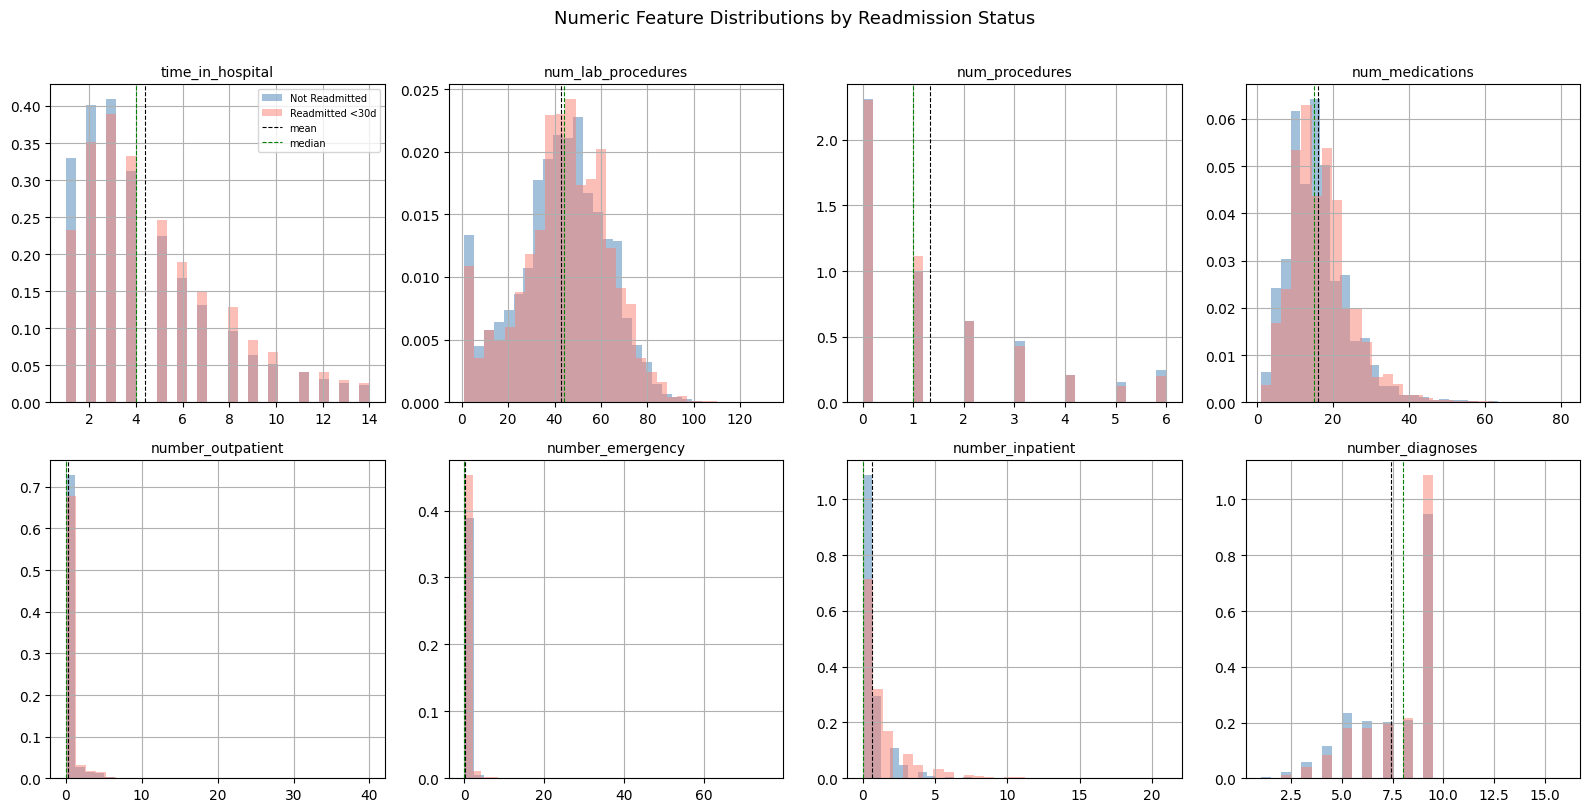

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    ax = axes[i]
    
    # Plot distribution split by target
    train_df[train_df["target_30day_readmit"] == 0][col].hist(
        bins=30, alpha=0.5, color="steelblue", 
        label="Not Readmitted", ax=ax, density=True
    )
    train_df[train_df["target_30day_readmit"] == 1][col].hist(
        bins=30, alpha=0.5, color="salmon", 
        label="Readmitted <30d", ax=ax, density=True
    )
    
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.axvline(train_df[col].mean(), color='black', 
               linestyle='--', linewidth=0.8, label="mean")
    ax.axvline(train_df[col].median(), color='green', 
               linestyle='--', linewidth=0.8, label="median")

axes[0].legend(fontsize=7)
plt.suptitle("Numeric Feature Distributions by Readmission Status", 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [92]:
numeric_by_target = (
    train_df
    .groupby(TARGET_COL)[numeric_features]
    .agg(["mean", "median", "std"])
)

display(numeric_by_target)

time_in_hospital                  num_lab_procedures                   num_procedures                  num_medications                  number_outpatient                   \
                                 mean median       std               mean median        std           mean median       std            mean median       std              mean median       std   
target_30day_readmit                                                                                                                                                                              
0                            4.329444    4.0  2.954703          42.747952   44.0  19.615785       1.339594    1.0  1.709704       15.867183   15.0  8.111387          0.360433    0.0  1.237851   
1                            4.762585    4.0  3.023145          44.287316   45.0  19.209676       1.260717    1.0  1.623369       16.885469   16.0  8.073782          0.439987    0.0  1.291678   

                     number_emergency                  number_inpatient                  number_diagnoses                   
                                 mean median       std             mean median       std             mean median       std  
target_30day_readmit                                                                                                        
0                            0.178612    0.0  0.875767         0.555683    0.0  1.111232         7.360987    8.0  1.961099  
1                            0.354034    0.0  1.363667         1.218290    1.0  1.918319         7.689492    9.0  1.786992

In [94]:
from scipy.stats import mannwhitneyu, pointbiserialr

numeric_test_results = []

for col in numeric_features:
    group0 = train_df.loc[train_df[TARGET_COL] == 0, col].dropna()
    group1 = train_df.loc[train_df[TARGET_COL] == 1, col].dropna()

    u_stat, p_value = mannwhitneyu(group0, group1, alternative="two-sided")
    r, r_p = pointbiserialr(train_df[TARGET_COL], train_df[col])

    numeric_test_results.append({
        "feature": col,
        "mw_u_stat": u_stat,
        "mw_p_value": p_value,
        "pointbiserial_r": r,
        "pointbiserial_p": r_p,
        "mean_target0": group0.mean(),
        "mean_target1": group1.mean(),
        "median_target0": group0.median(),
        "median_target1": group1.median(),
    })

numeric_test_results = pd.DataFrame(numeric_test_results)
display(numeric_test_results.sort_values("pointbiserial_r", ascending=False))

,feature,mw_u_stat,mw_p_value,pointbiserial_r,pointbiserial_p,mean_target0,mean_target1,median_target0,median_target1
6,number_inpatient,250913870.0,0.000000e+00,0.168906,0.000000e+00,0.555683,1.218290,0.0,1.0
5,number_emergency,299437863.5,2.432928e-77,0.059015,2.630542e-62,0.178612,0.354034,0.0,0.0
7,number_diagnoses,291682970.5,7.200867e-50,0.053762,5.316487e-52,7.360987,7.689492,8.0,9.0
0,time_in_hospital,290172326.5,1.141815e-49,0.046483,2.651667e-39,4.329444,4.762585,4.0,4.0
3,num_medications,292992683.5,1.501641e-40,0.039945,1.844524e-29,15.867183,16.885469,15.0,16.0
1,num_lab_procedures,306114714.5,3.554129e-12,0.025028,1.669338e-12,42.747952,44.287316,44.0,45.0
4,number_outpatient,306779000.5,1.020303e-24,0.020348,9.516930e-09,0.360433,0.439987,0.0,0.0
2,num_procedures,325085912.0,1.703997e-02,-0.014765,3.120750e-05,1.339594,1.260717,1.0,1.0


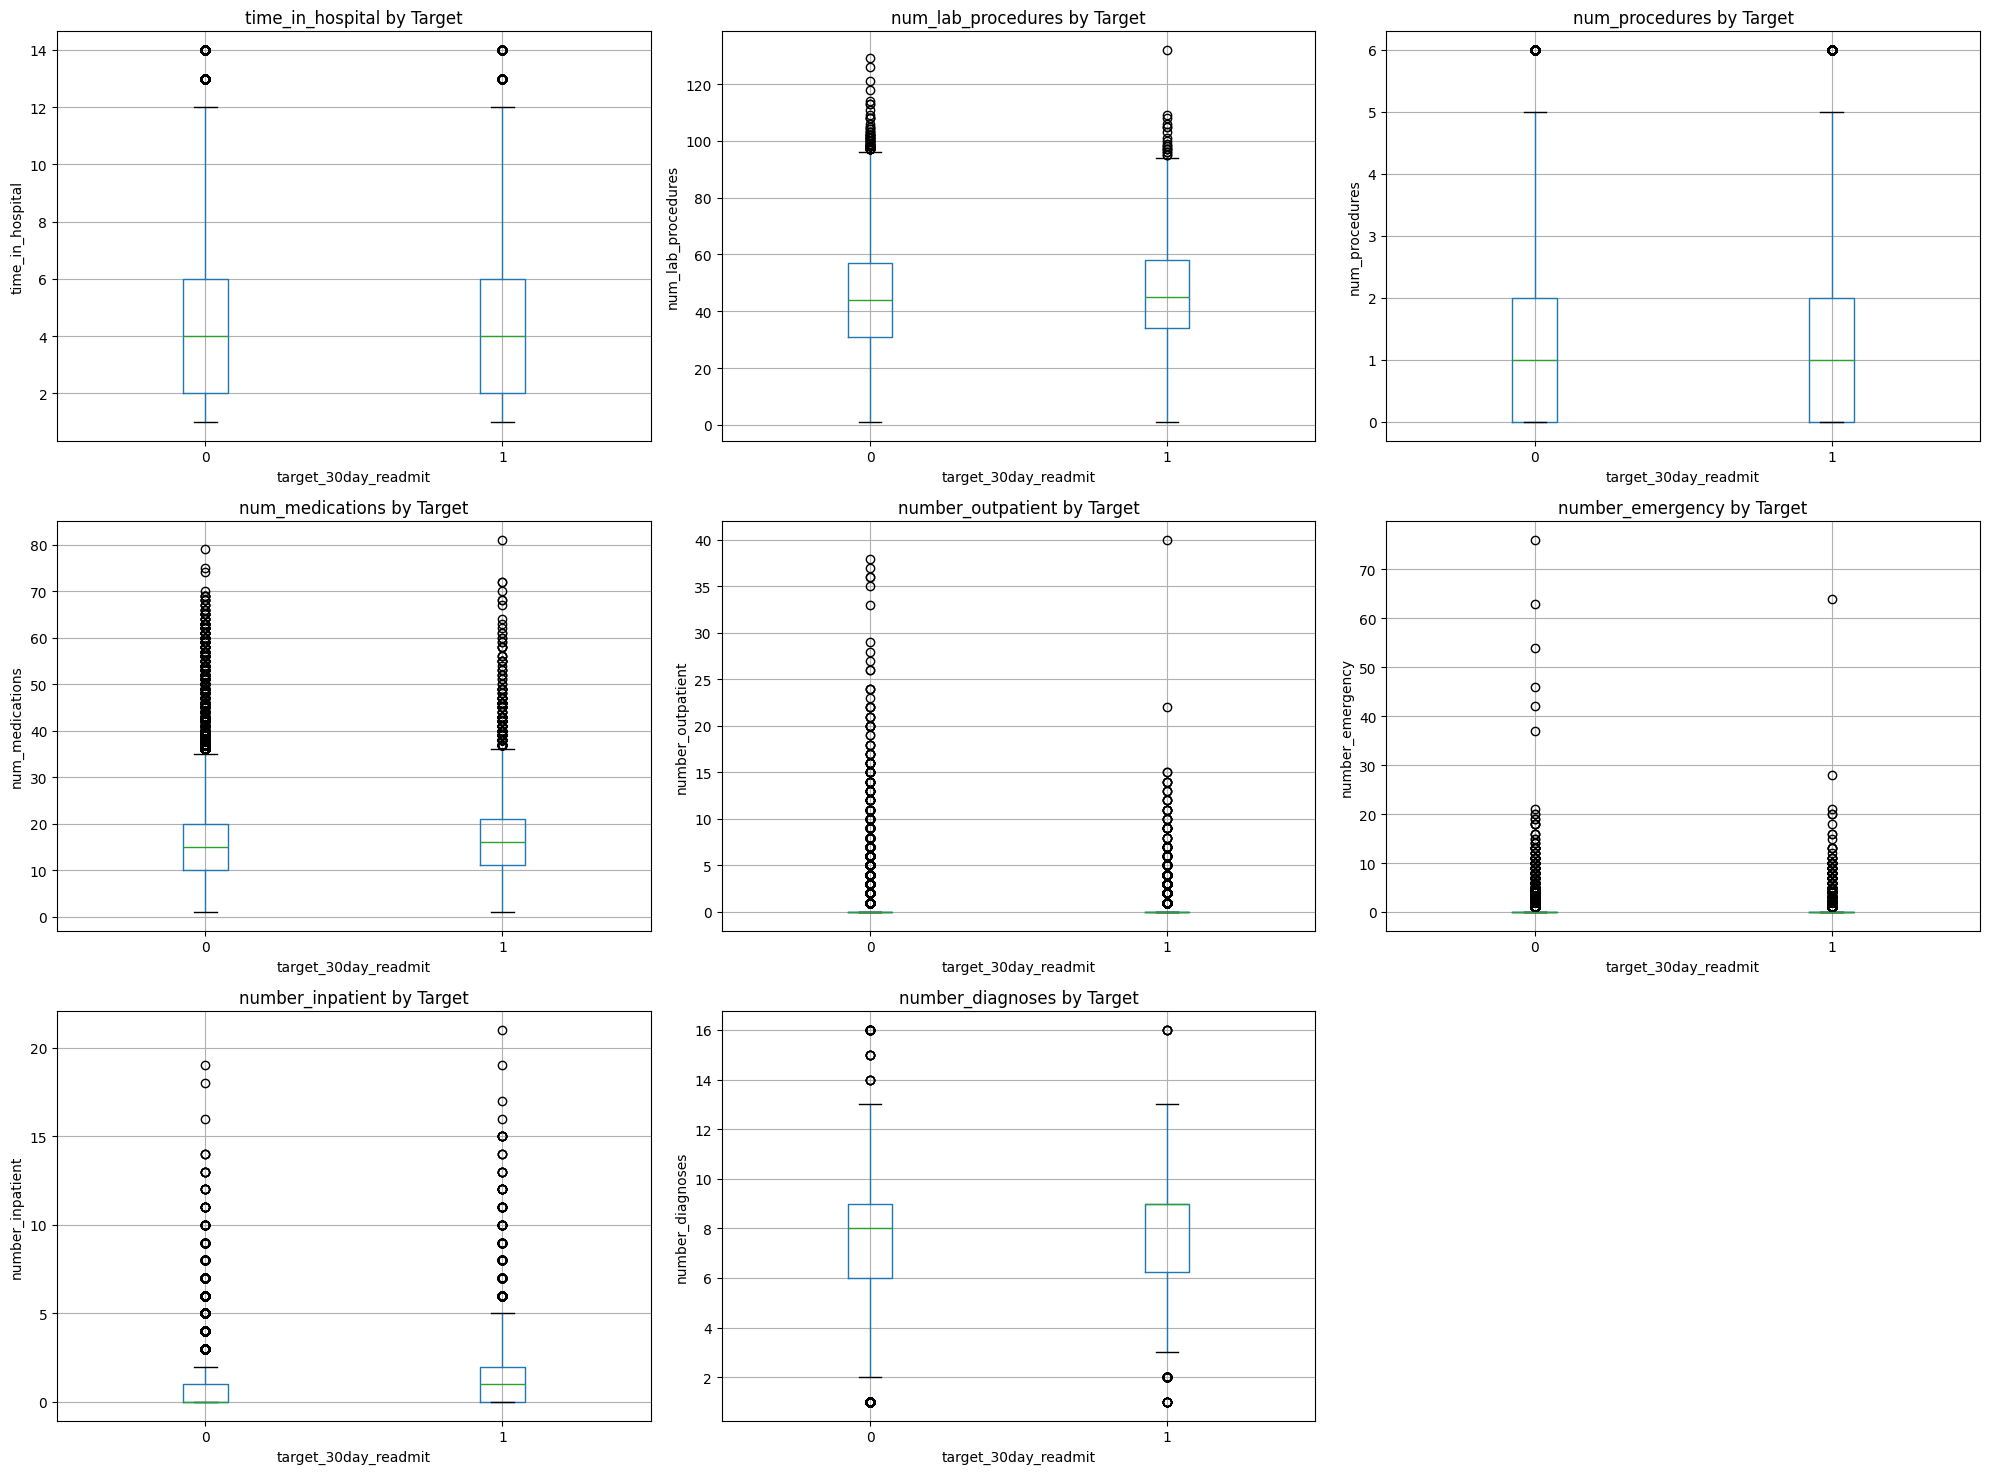

In [99]:

plt.figure(figsize=(20, 15))

for i, col in enumerate(numeric_features, 1):
        plt.subplot(3, 3, i)  # Adjust the grid size (3x3) based on the number of numeric features
        train_df.boxplot(column=col, by=TARGET_COL, ax=plt.gca())
        plt.title(f"{col} by Target")
        plt.suptitle("")
        plt.xlabel("target_30day_readmit")
        plt.ylabel(col)

plt.tight_layout()

plt.show()

### Numeric Feature Analysis — Key Findings

Mann-Whitney U tests confirm statistically significant differences 
between readmitted and non-readmitted groups for all numeric 
features (all p < 0.05). However effect sizes are uniformly small 
(point-biserial r < 0.17), consistent with the known difficulty 
of predicting 30-day readmission from encounter-level data alone.

**number_inpatient** is the strongest numeric predictor (r = 0.169) 
— readmitted patients had more than double the mean prior 
inpatient visits (1.22 vs 0.56). Prior hospitalization history 
is a well-established readmission risk factor in the clinical 
literature.

**num_procedures** shows a small negative association (r = -0.015) 
— patients receiving more procedures during the encounter had 
marginally lower readmission rates, consistent with more 
thorough inpatient treatment reducing acute readmission risk.

**number_outpatient, number_emergency, number_inpatient** are 
severely zero-inflated (67-89% zeros) with extreme right skew 
(skewness 3.5 to 24.9). Binary flags (any prior utilization) 
and log transforms are applied to make these distributions 
more suitable for modeling.

**num_lab_procedures and number_diagnoses** show mild or negative 
skew and require no transformation.

Note: Statistical significance is near-universal due to large 
sample size (n=79,541). Effect sizes rather than p-values 
drive feature retention decisions.

### Numeric Feature Transformations

No power transformations (log, Box-Cox) are applied to numeric 
features. Justification:

- Zero-inflated utilization variables (number_inpatient, 
  number_emergency, number_outpatient) are addressed through 
  binary flags — log transform on variables with 67-89% zeros 
  achieves negligible distributional improvement
- Remaining numeric features have moderate skew (< 1.5) and 
  bounded ranges — insufficient justification for transformation
- XGBoost is invariant to monotonic transformations — splits 
  are rank-based and unaffected by scaling or transformation
- Logistic regression features are StandardScaled — centering 
  and scaling addresses the practical modeling concern without 
  distorting clinical interpretability

Raw values are retained for all numeric features. Binary 
utilization flags are added as complementary engineered features.

From these variables, additional features will be derived:

- **any_prior_inpatient** — whether the patient had a previous
  hospital admission
- **any_prior_emergency** — whether the patient had a previous
  emergency department visit
- **total_prior_visits** — total healthcare utilization across
  outpatient, emergency, and inpatient encounters

In [100]:
# ---- Utilization feature engineering ----

train_df["any_prior_outpatient"] = (train_df["number_outpatient"] > 0).astype(int)
train_df["any_prior_emergency"] = (train_df["number_emergency"] > 0).astype(int)
train_df["any_prior_inpatient"] = (train_df["number_inpatient"] > 0).astype(int)

train_df["total_prior_visits"] = (
    train_df["number_outpatient"]
    + train_df["number_emergency"]
    + train_df["number_inpatient"]
)

In [101]:
util_cols = [
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "any_prior_outpatient",
    "any_prior_emergency",
    "any_prior_inpatient",
    "total_prior_visits",
]

display(train_df[util_cols].describe())

print("\nReadmission rate by prior inpatient flag:")
display(pd.crosstab(train_df["any_prior_inpatient"], train_df[TARGET_COL], normalize="index"))

print("\nReadmission rate by prior emergency flag:")
display(pd.crosstab(train_df["any_prior_emergency"], train_df[TARGET_COL], normalize="index"))

print("\nReadmission rate by prior outpatient flag:")
display(pd.crosstab(train_df["any_prior_outpatient"], train_df[TARGET_COL], normalize="index"))

,number_outpatient,number_emergency,number_inpatient,any_prior_outpatient,any_prior_emergency,any_prior_inpatient,total_prior_visits
count,79541.000000,79541.000000,79541.000000,79541.000000,79541.000000,79541.000000,79541.000000
mean,0.369533,0.198677,0.631473,0.165060,0.112194,0.334079,1.199683
std,1.244375,0.946064,1.248577,0.371237,0.315607,0.471671,2.269180
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,2.000000
max,40.000000,76.000000,21.000000,1.000000,1.000000,1.000000,80.000000



Readmission rate by prior inpatient flag:


target_30day_readmit,0,1
any_prior_inpatient,,
0,0.914137,0.085863
1,0.828774,0.171226



Readmission rate by prior emergency flag:


target_30day_readmit,0,1
any_prior_emergency,,
0,0.892873,0.107127
1,0.828216,0.171784



Readmission rate by prior outpatient flag:


target_30day_readmit,0,1
any_prior_outpatient,,
0,0.890878,0.109122
1,0.859014,0.140986


An additional utilization feature is constructed to reflect the fact that
not all prior healthcare encounters carry the same clinical severity.
Prior inpatient admissions are treated as higher-acuity events than
emergency visits, which in turn are treated as higher-acuity events than
outpatient encounters.

This yields a simple acuity-weighted utilization score:

- inpatient visits × 3
- emergency visits × 2
- outpatient visits × 1

The resulting feature complements `total_prior_visits` by capturing
severity-weighted utilization burden rather than raw encounter volume alone.

In [102]:
train_df["prior_utilization_score"] = (
    train_df["number_inpatient"] * 3
    + train_df["number_emergency"] * 2
    + train_df["number_outpatient"] * 1
)

In [103]:
print("Summary of prior_utilization_score:")
display(train_df["prior_utilization_score"].describe())

print("\nMean prior_utilization_score by target:")
display(train_df.groupby(TARGET_COL)["prior_utilization_score"].mean().round(3))

Summary of prior_utilization_score:


count    79541.000000
mean         2.661307
std          4.908957
min          0.000000
25%          0.000000
50%          0.000000
75%          3.000000
max        160.000000
Name: prior_utilization_score, dtype: float64


Mean prior_utilization_score by target:


target_30day_readmit
0    2.385
1    4.803
Name: prior_utilization_score, dtype: float64

### Encounter Intensity Features

Two interaction features can be constructed to normalize treatment and
diagnostic burden relative to the length of the hospital stay.

- **med_intensity** — medications per hospital day
- **lab_intensity** — laboratory procedures per hospital day

These features capture the intensity of clinical management during
the encounter. For example, a patient receiving many medications
during a short hospital stay represents more aggressive treatment
than a patient receiving the same number of medications during a
much longer stay.

Normalizing by length of stay therefore provides a more interpretable
measure of treatment and diagnostic intensity.

In [104]:
# ---- Encounter intensity features ----

train_df["med_intensity"] = (
    train_df["num_medications"] / train_df["time_in_hospital"]
)

train_df["lab_intensity"] = (
    train_df["num_lab_procedures"] / train_df["time_in_hospital"]
)

In [106]:
len(train_df.columns)

65

## Feature engineering categorical hospital codes

In [107]:
for col in [
    "admission_type_id",
    "admission_source_id",
    "discharge_disposition_id"
]:
    print(f"\n{col}")
    print(train_df[col].value_counts().sort_index())


admission_type_id
admission_type_id
1    41826
2    14641
3    14902
4       10
5     3701
6     4195
7       17
8      249
Name: count, dtype: int64

admission_source_id
admission_source_id
1     23382
2       865
3       133
4      2514
5       631
6      1829
7     44691
8        13
9       101
10        8
11        2
13        1
14        2
17     5233
20      123
22       11
25        2
Name: count, dtype: int64

discharge_disposition_id
discharge_disposition_id
1     48204
2      1703
3     11223
4       656
5       943
6     10309
7       491
8        88
9        18
10        3
12        3
15       56
16        8
17       13
18     2940
22     1588
23      344
24       38
25      806
27        4
28      103
Name: count, dtype: int64


### Admission Type Feature Engineering

`admission_type_id` encodes the type of hospital admission.
The original variable contains administrative categories that
are either extremely rare or represent missing information.

To improve interpretability and avoid sparse categories,
the variable is collapsed into five groups:

- **Emergency**
- **Urgent**
- **Elective**
- **Other** (rare categories such as newborn or trauma)
- **Unknown** (administrative missing values)

This preserves clinically meaningful distinctions between
planned and unplanned admissions while stabilizing the feature
distribution for modeling.

In [108]:
def map_admission_type(x):
    
    if x == 1:
        return "Emergency"
    
    elif x == 2:
        return "Urgent"
    
    elif x == 3:
        return "Elective"
    
    elif x in [4,7,8]:
        return "Other"
    
    elif x in [5,6]:
        return "Unknown"
    
    else:
        return "Unknown"


train_df["admission_type"] = train_df["admission_type_id"].apply(map_admission_type)
print(train_df["admission_type"].value_counts())

admission_type
Emergency    41826
Elective     14902
Urgent       14641
Unknown       7896
Other          276
Name: count, dtype: int64


### Admission Source Feature Engineering

`admission_source_id` describes where the patient was admitted from.
The raw variable contains many administrative categories, several of
which are extremely rare.

To stabilize the feature and preserve clinically meaningful distinctions,
the variable is collapsed into four groups:

- **Physician_Referral** — referred by physician, clinic, or HMO
- **Emergency_Room** — admitted through the emergency department
- **Transfer** — transferred from another hospital or health facility
- **Other / Unknown** — rare or administrative categories

This grouping captures differences in admission context while avoiding
sparse categorical levels.

In [109]:
def map_admission_source(x):

    if x in [1,2,3]:
        return "Physician_Referral"
    
    elif x == 7:
        return "Emergency_Room"
    
    elif x in [4,5,6,17]:
        return "Transfer"
    
    elif pd.isna(x):
        return "Unknown"
    
    else:
        return "Other"


train_df["admission_source"] = train_df["admission_source_id"].apply(map_admission_source)
print(train_df["admission_source"].value_counts())

admission_source
Emergency_Room        44691
Physician_Referral    24380
Transfer              10207
Other                   263
Name: count, dtype: int64


### Discharge Disposition Feature Engineering

`discharge_disposition_id` describes the patient’s destination after
leaving the hospital. The raw variable contains many administrative
categories, several of which are rare.

To improve interpretability and reduce sparsity, discharge disposition
is collapsed into clinically meaningful groups:

- **Home** — discharged home
- **Skilled_Nursing** — discharged to a skilled nursing or nursing facility
- **Home_Health** — discharged home with healthcare services
- **Transfer** — transferred to another inpatient or acute-care facility
- **Rehab** — discharged to a rehabilitation facility
- **Long_Term_Care** — discharged to a long-term care hospital
- **AMA** — left against medical advice
- **Other** — rare institutional or administrative categories
- **Unknown** — unclassified categories

This grouping preserves meaningful differences in post-discharge care
intensity while producing a more stable feature for modeling.

**Modeling note:** `discharge_disposition_id` is only appropriate if the
prediction is assumed to occur at or near discharge. It would not be
valid for a model intended to generate predictions at admission time.

In [110]:
def map_discharge_disposition(x):

    if x == 1:
        return "Home"

    elif x in [3, 15, 24]:
        return "Skilled_Nursing"

    elif x == 6:
        return "Home_Health"

    elif x in [2, 4, 5]:
        return "Transfer"

    elif x == 22:
        return "Rehab"

    elif x == 23:
        return "Long_Term_Care"

    elif x == 7:
        return "AMA"

    elif x in [18, 25]:
        return "Other"

    else:
        return "Unknown"


train_df["discharge_disposition"] = (
    train_df["discharge_disposition_id"].apply(map_discharge_disposition)
)

print(train_df["discharge_disposition"].value_counts())

discharge_disposition
Home               48204
Skilled_Nursing    11317
Home_Health        10309
Other               3746
Transfer            3302
Rehab               1588
AMA                  491
Long_Term_Care       344
Unknown              240
Name: count, dtype: int64


### Institutional Discharge Feature

Patients discharged to institutional care settings such as
skilled nursing facilities, rehabilitation centers, or
long-term care hospitals often represent a higher clinical
acuity population than patients discharged directly home.

A binary **institutional_discharge** feature is therefore
constructed to distinguish:

- **Home discharge**
- **Institutional discharge**

This feature captures a clinically meaningful grouping of
post-discharge care intensity that may not be fully captured
by the individual discharge categories alone.

In [111]:
train_df["institutional_discharge"] = (
    train_df["discharge_disposition"].isin([
        "Skilled_Nursing",
        "Rehab",
        "Long_Term_Care",
        "Transfer"
    ])
).astype(int)

train_df["institutional_discharge"].value_counts()

institutional_discharge
0    62990
1    16551
Name: count, dtype: int64

### Medical Specialty Feature Engineering

`medical_specialty` represents the physician specialty responsible
for the patient encounter. The raw variable contains more than
70 distinct categories, many of which occur very rarely.

Using the raw categories would introduce excessive sparsity and
high dimensionality when one-hot encoded.

Instead, specialties are grouped into clinically meaningful
service categories based on broad clinical domains:

- Primary_Care
- Emergency
- Cardiology
- Surgery
- Orthopedics
- Nephrology
- Pulmonology
- Mental_Health
- Radiology
- Specialty_Medicine
- Other

This grouping preserves clinically relevant distinctions while
reducing dimensionality and improving model stability.

In [116]:
print(train_df["medical_specialty"].value_counts(dropna=False).head(30))
print(train_df["medical_specialty"].value_counts(normalize=True))

medical_specialty
NaN                                  38914
InternalMedicine                     11463
Emergency/Trauma                      5989
Family/GeneralPractice                5766
Cardiology                            4269
Surgery-General                       2431
Nephrology                            1220
Orthopedics                           1087
Orthopedics-Reconstructive             990
Radiologist                            884
Pulmonology                            707
Psychiatry                             671
Urology                                543
ObstetricsandGynecology                516
Surgery-Cardiovascular/Thoracic        505
Surgery-Vascular                       416
Gastroenterology                       415
Surgery-Neuro                          352
PhysicalMedicineandRehabilitation      308
Oncology                               254
Pediatrics                             206
Neurology                              157
Hematology/Oncology                 

In [115]:
print("Raw missing medical_specialty in train:")
print(train_df["medical_specialty"].isna().sum())

print("\nMapped Unknown in medical_specialty_group:")
print((train_df["medical_specialty_group"] == "Unknown").sum())

Raw missing medical_specialty in train:
38914

Mapped Unknown in medical_specialty_group:
38914


In [114]:
def map_medical_specialty(x):

    if pd.isna(x) or x == "?":
        return "Unknown"

    x = str(x)

    if x in ["InternalMedicine", "Family/GeneralPractice", "Hospitalist"]:
        return "Primary_Care"

    elif x == "Emergency/Trauma":
        return "Emergency"

    elif x.startswith("Cardiology"):
        return "Cardiology"

    elif x.startswith("Surgery"):
        return "Surgery"

    elif x.startswith("Orthopedics"):
        return "Orthopedics"

    elif x == "Nephrology":
        return "Nephrology"

    elif x == "Pulmonology":
        return "Pulmonology"

    elif x in ["Psychiatry", "Psychology", "Psychiatry-Child/Adolescent"]:
        return "Mental_Health"

    elif x in ["Radiology", "Radiologist"]:
        return "Radiology"

    elif x in [
        "Neurology",
        "Gastroenterology",
        "Oncology",
        "Hematology/Oncology",
        "Endocrinology",
        "Endocrinology-Metabolism",
        "InfectiousDiseases"
    ]:
        return "Specialty_Medicine"

    else:
        return "Other"


train_df["medical_specialty_group"] = (
    train_df["medical_specialty"].apply(map_medical_specialty)
)

print(train_df["medical_specialty_group"].value_counts())

medical_specialty_group
Unknown               38914
Primary_Care          17282
Emergency              5989
Cardiology             4275
Surgery                3926
Other                  2348
Orthopedics            2077
Nephrology             1220
Specialty_Medicine     1122
Radiology               929
Mental_Health           752
Pulmonology             707
Name: count, dtype: int64


In [117]:
pd.crosstab(
    train_df["medical_specialty_group"],
    train_df[TARGET_COL],
    normalize="index"
).sort_values(1, ascending=False)

target_30day_readmit,0,1
medical_specialty_group,,
Nephrology,0.843443,0.156557
Specialty_Medicine,0.862745,0.137255
Unknown,0.880686,0.119314
Primary_Care,0.881958,0.118042
Emergency,0.885123,0.114877
Pulmonology,0.885431,0.114569
Mental_Health,0.888298,0.111702
Surgery,0.897606,0.102394
Radiology,0.900969,0.099031


In [118]:
from scipy.stats import chi2_contingency
import numpy as np

ct = pd.crosstab(
    train_df["medical_specialty_group"],
    train_df["target_30day_readmit"]
)
chi2, p, dof, _ = chi2_contingency(ct)
n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

print(f"Chi-square: {chi2:.2f}")
print(f"P-value: {p:.6f}")
print(f"Cramér's V: {cramers_v:.4f}")

Chi-square: 132.12
P-value: 0.000000
Cramér's V: 0.0408


`medical_specialty` exhibits substantial missingness, with nearly half
of encounters lacking a recorded specialty. Rather than dropping the
feature entirely, missing values are retained as an explicit `Unknown`
category so that the model can learn whether absence of specialty
information itself carries signal.

## Feature engineering gender and race variables

In [119]:
train_df['gender'].value_counts(dropna=False)

gender
Female             42809
Male               36729
Unknown/Invalid        3
Name: count, dtype: int64

### Gender Data Cleaning

The `gender` variable contains three records labeled
`Unknown/Invalid`. These entries represent clear data
quality issues rather than a meaningful demographic category.

Because these observations account for fewer than 0.01% of the
dataset (3 out of ~79,000 encounters), they are removed during
data cleaning rather than retained as a separate category.

This avoids introducing an extremely sparse dummy variable
during one-hot encoding while having negligible impact on the
overall dataset.

In [124]:
train_df=train_df[train_df['gender']!='Unknown']
train_df['gender'].value_counts(dropna=False)

gender
Female    42809
Male      36729
Name: count, dtype: int64

In [121]:
train_df['race'].value_counts(dropna=False)

race
Caucasian          59334
AfricanAmerican    15065
NaN                 1816
Hispanic            1646
Other               1174
Asian                506
Name: count, dtype: int64

In [122]:
train_df['race'] = train_df['race'].fillna('Unknown')

# Step 2 — verify no unexpected values
print("Race value counts after filling:")
print(train_df['race'].value_counts())

# Step 3 — target association
print("\nReadmission rate by race:")
race_assoc = (
    train_df.groupby('race')['target_30day_readmit']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
    .round(3)
)
print(race_assoc)

# Step 4 — chi-square and Cramér's V
from scipy.stats import chi2_contingency
import numpy as np

ct = pd.crosstab(train_df['race'], train_df['target_30day_readmit'])
chi2, p, dof, _ = chi2_contingency(ct)
n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

print(f"\nChi-square: {chi2:.2f}")
print(f"P-value: {p:.6f}")
print(f"Cramér's V: {cramers_v:.4f}")

Race value counts after filling:
race
Caucasian          59334
AfricanAmerican    15065
Unknown             1816
Hispanic            1646
Other               1174
Asian                506
Name: count, dtype: int64

Readmission rate by race:
                  mean  count
race                         
AfricanAmerican  0.116  15065
Caucasian        0.115  59334
Asian            0.109    506
Hispanic         0.105   1646
Other            0.101   1174
Unknown          0.083   1816

Chi-square: 23.13
P-value: 0.000319
Cramér's V: 0.0171


### Race — Target Association

Readmission rates show minimal variation across racial groups 
(range: 10.1% to 11.6% among known categories). The difference 
between AfricanAmerican and Caucasian patients — the two largest 
groups — is 0.1 percentage points, clinically negligible.

Chi-square confirms a statistically significant association 
(χ² = 23.13, p < 0.001) however Cramér's V of 0.017 indicates 
near-zero effect size. Race carries minimal predictive signal 
for 30-day readmission in this dataset.

Unknown race shows a notably lower readmission rate (8.3%) 
compared to all identified racial groups — potentially reflecting 
systematic differences in encounter type or documentation 
practice for encounters where race was not recorded.

**Fairness implication:** The near-zero correlation between race 
and readmission outcome suggests the model is unlikely to learn 
racially disparate prediction patterns. Formal disparate impact 
analysis in Section F will verify this by comparing false 
positive and false negative rates across racial subgroups 
after model fitting.

In [125]:
train_df['change'].value_counts(dropna=False)

change
No    42639
Ch    36899
Name: count, dtype: int64

In [126]:
print("Readmission rate by change:")
print(
    train_df.groupby('change')['target_30day_readmit']
    .agg(['mean', 'count'])
    .round(3)
)

from scipy.stats import chi2_contingency
import numpy as np

ct = pd.crosstab(train_df['change'], train_df['target_30day_readmit'])
chi2, p, dof, _ = chi2_contingency(ct)
n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(f"\nChi-square: {chi2:.2f}, p={p:.6f}, Cramér's V={cramers_v:.4f}")

Readmission rate by change:
         mean  count
change              
Ch      0.120  36899
No      0.109  42639

Chi-square: 24.33, p=0.000001, Cramér's V=0.0175


In [128]:
ct = pd.crosstab(train_df['change'], train_df['target_30day_readmit'])
ct

target_30day_readmit,0,1
change,,
Ch,32457,4442
No,37983,4656


In [130]:
train_df['diabetesMed'].value_counts(normalize=True, dropna=False)

diabetesMed
Yes    0.772939
No     0.227061
Name: proportion, dtype: float64

In [131]:
print("Readmission rate by diabetesMed:")
print(
    train_df.groupby('diabetesMed')['target_30day_readmit']
    .agg(['mean', 'count'])
    .round(3)
)

ct = pd.crosstab(train_df['diabetesMed'], train_df['target_30day_readmit'])
chi2, p, dof, _ = chi2_contingency(ct)
n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(f"\nChi-square: {chi2:.2f}, p={p:.6f}, Cramér's V={cramers_v:.4f}")

Readmission rate by diabetesMed:
              mean  count
diabetesMed              
No           0.100  18060
Yes          0.119  61478

Chi-square: 48.28, p=0.000000, Cramér's V=0.0246


In [134]:
train_df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'medical_specialty', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'A1Cresult', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
       'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed',
       'readmitted', 'target_30day_readmit', 'age_ordinal', 'diag_1_category', 'diag_2_category', 'diag_3_category', 'diabetes_primary_diag', 'n_active_diabetes_meds', 'n_med_increases',
       'n_med_decreases

# Feature engineering is done here

## Final Modeling Dataset Construction

At this stage, feature engineering is complete, and the dataframe contains a mix of:

- raw source columns
- engineered features
- identifiers
- target variables

Before modeling, we must define a clean and defensible final predictor set.

### What we remove

We exclude:

- identifiers (`encounter_id`, `patient_nbr`)
- target columns (`readmitted`, `target_30day_readmit`)
- raw columns replaced by engineered versions
- sparse/high-cardinality raw fields that were intentionally grouped

### What we keep

We retain:

- engineered diagnosis, utilization, medication, and encounter features
- clinically meaningful grouped categorical variables
- numeric utilization and hospital encounter variables
- demographic variables such as race and gender

This produces the final model

In [136]:
cols_to_drop = [
    # Identifiers
    'encounter_id', 'patient_nbr',
    # Original target
    'readmitted',
    # Raw age
    'age',
    # Raw diagnosis
    'diag_1', 'diag_2', 'diag_3',
    # Raw ID encoded
    'admission_type_id', 
    'discharge_disposition_id', 
    'admission_source_id',
    # Raw contextual
    'medical_specialty',
] + medication_features

# Only drop what exists
cols_to_drop = [c for c in cols_to_drop if c in train_df.columns]
train_df = train_df.drop(columns=cols_to_drop)

print("Shape after dropping:", train_df.shape)
print("\nFinal columns:")
for col in sorted(train_df.columns.tolist()):
    print(f"  {col}")

Shape after dropping: (79538, 36)

Final columns:
  A1Cresult
  admission_source
  admission_type
  age_ordinal
  any_prior_emergency
  any_prior_inpatient
  any_prior_outpatient
  change
  diabetesMed
  diabetes_primary_diag
  diag_1_category
  diag_2_category
  diag_3_category
  discharge_disposition
  gender
  institutional_discharge
  insulin_change
  insulin_flag
  lab_intensity
  med_intensity
  medical_specialty_group
  n_active_diabetes_meds
  n_med_decreases
  n_med_increases
  num_lab_procedures
  num_medications
  num_procedures
  number_diagnoses
  number_emergency
  number_inpatient
  number_outpatient
  prior_utilization_score
  race
  target_30day_readmit
  time_in_hospital
  total_prior_visits


In [138]:
# Basic validation of final modeling dataset
print("Missing values by column:")
display(train_df.isna().sum().sort_values(ascending=False))

print("\nTarget distribution:")
display(
    train_df["target_30day_readmit"]
    .value_counts(normalize=True)
    .rename("proportion")
)

print("\nData types:")
display(train_df.dtypes)


Missing values by column:


race                       0
gender                     0
n_med_increases            0
n_med_decreases            0
insulin_flag               0
insulin_change             0
any_prior_inpatient        0
any_prior_emergency        0
total_prior_visits         0
any_prior_outpatient       0
prior_utilization_score    0
med_intensity              0
lab_intensity              0
admission_type             0
admission_source           0
discharge_disposition      0
institutional_discharge    0
n_active_diabetes_meds     0
diabetes_primary_diag      0
diag_3_category            0
number_inpatient           0
time_in_hospital           0
num_lab_procedures         0
num_procedures             0
num_medications            0
number_outpatient          0
number_emergency           0
number_diagnoses           0
diag_2_category            0
A1Cresult                  0
change                     0
diabetesMed                0
target_30day_readmit       0
age_ordinal                0
diag_1_categor


Target distribution:


target_30day_readmit
0    0.885614
1    0.114386
Name: proportion, dtype: float64


Data types:


race                        object
gender                      object
time_in_hospital             int64
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
number_diagnoses             int64
A1Cresult                   object
change                      object
diabetesMed                 object
target_30day_readmit         int64
age_ordinal                  int64
diag_1_category             object
diag_2_category             object
diag_3_category             object
diabetes_primary_diag        int64
n_active_diabetes_meds       int64
n_med_increases              int64
n_med_decreases              int64
insulin_flag                 int64
insulin_change               int64
any_prior_inpatient          int64
any_prior_emergency          int64
total_prior_visits           int64
any_prior_outpatient         int64
prior_utilization_sc

In [139]:
TARGET_COLUMN = "target_30day_readmit"

X_train = train_df.drop(columns=[TARGET_COLUMN])
y_train = train_df[TARGET_COLUMN]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (79538, 35)
y_train shape: (79538,)


# Handling numeric and categorical variables

In [150]:
# ==============================
# Define feature families
# ==============================

# Binary categorical features
binary_features = [
    "gender",
    "change",
    "diabetesMed"
]

# One-hot categorical features
categorical_features = [
    "race",
    "A1Cresult",
    "admission_type",
    "admission_source",
    "discharge_disposition",
    "medical_specialty_group",
    "diag_1_category",
    "diag_2_category",
    "diag_3_category"

]

# Numeric features
numeric_features = [
    col for col in X_train.columns
    if col not in binary_features + categorical_features
]

print("Numeric features:", len(numeric_features))
print("Binary features:", len(binary_features))
print("Categorical features:", len(categorical_features))


Numeric features: 23
Binary features: 3
Categorical features: 9


In [153]:
# ==============================
# Binary encoding
# ==============================

X_train["gender"] = X_train["gender"].map({
    "Female": 0,
    "Male": 1
})

X_train["change"] = X_train["change"].map({
    "No": 0,
    "Ch": 1
})

X_train["diabetesMed"] = X_train["diabetesMed"].map({
    "No": 0,
    "Yes": 1
})


In [154]:
# ==============================
# One-hot encode categorical variables
# ==============================

X_train = pd.get_dummies(
    X_train,
    columns=categorical_features,
    drop_first=True
)

print("Shape after encoding:", X_train.shape)

Shape after encoding: (79538, 84)


### Final Feature Sanity Check

Before model training, the engineered feature matrix is audited to ensure:

- all predictors are numeric
- no unexpected missing values remain
- constant or near-constant features are identified
- duplicate columns are removed
- no leakage-related variables remain in the model matrix

This final validation step helps ensure that downstream modeling results are driven by legitimate predictors rather than data quality issues or pipeline errors.


In [155]:
print("Non-numeric columns:")
print(X_train.select_dtypes(include=["object", "category"]).columns.tolist())

Non-numeric columns:
[]


In [156]:
missing_summary = (
    X_train.isna().sum()
    .sort_values(ascending=False)
)

print("Top missing-value columns:")
display(missing_summary[missing_summary > 0].head(20))

print("Total columns with missing values:", (missing_summary > 0).sum())


Top missing-value columns:


Series([], dtype: int64)

Total columns with missing values: 0


In [157]:
constant_features = [col for col in X_train.columns if X_train[col].nunique() <= 1]

print("Constant features:")
print(constant_features)
print("Number of constant features:", len(constant_features))


Constant features:
[]
Number of constant features: 0


In [159]:
near_constant_summary = []

for col in X_train.columns:
    vc = X_train[col].value_counts(normalize=True, dropna=False)
    top_freq = vc.iloc[0]
    near_constant_summary.append((col, top_freq))

near_constant_df = pd.DataFrame(near_constant_summary, columns=["feature", "top_frequency"])
near_constant_df = near_constant_df.sort_values("top_frequency", ascending=False)

very_near_constant = near_constant_df.loc[near_constant_df["top_frequency"] > 0.995, "feature"].tolist()

print("Very near-constant features (>99.5% one value):")
print(very_near_constant)


Very near-constant features (>99.5% one value):
['discharge_disposition_Unknown', 'admission_source_Other', 'admission_type_Other', 'discharge_disposition_Long_Term_Care']


### Near-Constant Feature Removal

Four one-hot encoded dummy variables were removed due to 
near-zero variance (>99.5% single value):

- discharge_disposition_Unknown
- discharge_disposition_Long_Term_Care  
- admission_source_Other
- admission_type_Other

Features with near-constant values cannot contribute meaningful 
signal to either tree-based or linear models and introduce 
unnecessary noise into feature importance calculations. 
Threshold: features where a single value accounts for >99.5% 
of observations.

In [160]:
duplicate_cols = X_train.columns[X_train.T.duplicated()].tolist()

print("Duplicated columns:")
print(duplicate_cols)
print("Number of duplicated columns:", len(duplicate_cols))


Duplicated columns:
['diag_1_category_Diabetes']
Number of duplicated columns: 1


In [161]:
if duplicate_cols:
    X_train = X_train.loc[:, ~X_train.T.duplicated()]

In [162]:
suspicious_cols = [
    "readmitted",
    "target_30day_readmit",
    "encounter_id",
    "patient_nbr"
]

print("Suspicious columns still present:")
print([c for c in suspicious_cols if c in X_train.columns])


Suspicious columns still present:
[]


In [164]:
processed_dir=PROJECT_ROOT/'data'/'processed'
X_train.to_csv(processed_dir/'X_train.csv', index=False)
y_train.to_csv(processed_dir/'y_train.csv', index=False)
test_df.to_csv(processed_dir/'test_df_engineered.csv', index=False)

In [165]:
feature_columns = X_train.columns.tolist()

with open(processed_dir / "feature_columns.txt", "w") as f:
    for col in feature_columns:
        f.write(col + "\n")

print("Saved feature column list.")

Saved feature column list.
